In [109]:
from pathlib import Path

# ====== Data paths ======
DATA_DIR = Path("/home/danila/networks/data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VALID_CSV = DATA_DIR / "valid_split.csv"

# Embedding dirs
WAVLM_DIR = DATA_DIR / "embeddings" / "audio_wavlm_large_fps5_v1"
ER_DIR    = DATA_DIR / "embeddings" / "audio_superb_wav2vec2_large_er_fps5_v1"

# ====== Training setup ======
DEVICE = "cuda"
SEED = 42

EMOTIONS = ["Admiration","Amusement","Determination","Empathic Pain","Excitement","Joy"]
NUM_TARGETS = 6

ID_WIDTH = 5

# ====== Sequence / alignment ======
# Both audio sets are binned at 5 fps
USE_VALID_MASK = True

# ====== Batch ======
BATCH_SIZE = 32
NUM_WORKERS = 4
PIN_MEMORY = True

# ====== Model ======
D_MODEL = 192 #256
TCN_LAYERS = 6
TCN_KERNEL = 3
DROPOUT = 0.3
ATTN_HIDDEN = 128

USE_SIGMOID_OUTPUT = False

# ====== Augmentation (time masking on embeddings) ======
USE_TIME_MASK = True
TIME_MASK_PROB = 0.3
TIME_MASK_MAX_RATIO = 0.08
TIME_MASK_NUM = 1            # number of masks per sample

# ====== Optimization ======
LR = 5e-4
WEIGHT_DECAY = 3e-2
MAX_EPOCHS = 50
GRAD_CLIP_NORM = 1.0
USE_AMP = True

# ====== Loss mix ======
ALPHA_PEARSON = 0.2  # 0.5*(1-corr) + 0.5*MSE

# ====== Early stopping ======
PATIENCE = 8
MIN_DELTA = 1e-4

# ====== Checkpoints / logs ======
OUT_DIR = DATA_DIR / "runs" / "audio_only_variant1_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = OUT_DIR / "best.pt"
HIST_PATH = OUT_DIR / "history.json"

In [2]:
import os, json, math, random
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("CUDA:", torch.cuda.is_available(), "| DEVICE:", DEVICE)

CUDA: True | DEVICE: cuda


In [3]:
def pearson_corr_torch(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Differentiable Pearson correlation averaged over columns."""
    vx = preds - preds.mean(0)
    vy = targets - targets.mean(0)
    corr = (vx * vy).sum(0) / (torch.sqrt((vx**2).sum(0) * (vy**2).sum(0)) + 1e-8)
    return corr.mean()

class PearsonLoss(nn.Module):
    def forward(self, preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return 1.0 - pearson_corr_torch(preds, targets)

pearson_loss_fn = PearsonLoss()
mse_loss_fn = nn.MSELoss()

In [4]:
train_df = pd.read_csv(TRAIN_CSV, dtype={"Filename": str})
valid_df = pd.read_csv(VALID_CSV, dtype={"Filename": str})

train_df["Filename"] = train_df["Filename"].str.zfill(ID_WIDTH)
valid_df["Filename"] = valid_df["Filename"].str.zfill(ID_WIDTH)

print("Train:", len(train_df), "Val:", len(valid_df))
train_df.head()

Train: 8072 Val: 4588


,Filename,Admiration,Amusement,Determination,Empathic Pain,Excitement,Joy
0,00000,0.333333,0.333333,0.0,0.0,0.333333,0.0
1,00001,0.000000,0.000000,0.0,0.0,0.500000,0.0
2,00002,0.500000,0.000000,0.0,0.0,0.000000,0.0
3,00003,0.000000,0.000000,0.5,0.0,0.000000,0.0
4,00004,0.400000,0.000000,0.0,0.0,0.200000,0.4


In [5]:
def load_npz_embeddings(npz_path: Path) -> Tuple[np.ndarray, np.ndarray]:
    """
    returns:
      emb: (T, H) float32
      valid: (T,) bool
    """
    d = np.load(npz_path, allow_pickle=False)
    emb = d["embeddings"]
    # embeddings могли быть float16
    emb = emb.astype(np.float32)
    valid = d["valid"].astype(np.bool_) if "valid" in d.files else np.ones((emb.shape[0],), dtype=np.bool_)
    return emb, valid

class AudioEmbDataset(Dataset):
    def __init__(self, df: pd.DataFrame, wavlm_dir: Path, er_dir: Path):
        self.df = df.reset_index(drop=True)
        self.wavlm_dir = wavlm_dir
        self.er_dir = er_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.df.iloc[idx]
        vid = str(row["Filename"]).zfill(ID_WIDTH)

        wavlm_path = self.wavlm_dir / f"{vid}.npz"
        er_path    = self.er_dir / f"{vid}.npz"

        if not wavlm_path.exists():
            raise FileNotFoundError(f"Missing WavLM npz: {wavlm_path}")
        if not er_path.exists():
            raise FileNotFoundError(f"Missing ER npz: {er_path}")

        x_w, m_w = load_npz_embeddings(wavlm_path)
        x_e, m_e = load_npz_embeddings(er_path)

        T = min(x_w.shape[0], x_e.shape[0])
        x_w = x_w[:T]
        x_e = x_e[:T]
        m = (m_w[:T] & m_e[:T]) if USE_VALID_MASK else np.ones((T,), dtype=np.bool_)

        y = np.array([row[e] for e in EMOTIONS], dtype=np.float32)
        y = (y - y_mean) / y_std

        return {
            "video_id": vid,
            "x_wavlm": x_w,  # (T, H1)
            "x_er": x_e,     # (T, H2)
            "mask": m,       # (T,)
            "y": y           # (6,)
        }

def collate_pad(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    # lengths
    lengths = [b["x_wavlm"].shape[0] for b in batch]
    maxT = max(lengths)

    H1 = batch[0]["x_wavlm"].shape[1]
    H2 = batch[0]["x_er"].shape[1]

    xw = torch.zeros((len(batch), maxT, H1), dtype=torch.float32)
    xe = torch.zeros((len(batch), maxT, H2), dtype=torch.float32)
    mask = torch.zeros((len(batch), maxT), dtype=torch.bool)
    y = torch.zeros((len(batch), NUM_TARGETS), dtype=torch.float32)
    vids = []

    for i, b in enumerate(batch):
        T = b["x_wavlm"].shape[0]
        xw[i, :T] = torch.from_numpy(b["x_wavlm"])
        xe[i, :T] = torch.from_numpy(b["x_er"])
        mask[i, :T] = torch.from_numpy(b["mask"])
        y[i] = torch.from_numpy(b["y"])
        vids.append(b["video_id"])

    return {"video_id": vids, "x_wavlm": xw, "x_er": xe, "mask": mask, "y": y, "lengths": torch.tensor(lengths)}

In [6]:
MIN_VALID_BINS = 5 # not use otherwise

def filter_existing_pairs_and_valid(df, wavlm_dir, er_dir, id_width=5, min_valid_bins=5):
    keep_rows = []
    missing = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Filter missing/empty"):
        vid = str(row["Filename"]).zfill(id_width)
        wavlm_path = wavlm_dir / f"{vid}.npz"
        er_path    = er_dir / f"{vid}.npz"

        if not wavlm_path.exists() or not er_path.exists():
            reason = []
            if not wavlm_path.exists(): reason.append("wavlm_missing")
            if not er_path.exists(): reason.append("er_missing")
            missing.append({"video_id": vid, "reason": ",".join(reason)})
            continue

        # is there valid bins ?
        try:
            dw = np.load(wavlm_path, allow_pickle=False)
            de = np.load(er_path, allow_pickle=False)
            mw = dw["valid"].astype(bool) if "valid" in dw.files else np.ones((dw["embeddings"].shape[0],), bool)
            me = de["valid"].astype(bool) if "valid" in de.files else np.ones((de["embeddings"].shape[0],), bool)
            T = min(len(mw), len(me))
            m = mw[:T] & me[:T]
            if m.sum() < min_valid_bins:
                missing.append({"video_id": vid, "reason": f"too_few_valid<{min_valid_bins}"})
                continue
        except Exception as e:
            missing.append({"video_id": vid, "reason": f"npz_read_error:{repr(e)}"})
            continue

        keep_rows.append(row)

    return pd.DataFrame(keep_rows).reset_index(drop=True), pd.DataFrame(missing)


In [7]:
train_df_ok, train_missing = filter_existing_pairs_and_valid(train_df, WAVLM_DIR, ER_DIR, ID_WIDTH, MIN_VALID_BINS)
valid_df_ok, valid_missing = filter_existing_pairs_and_valid(valid_df, WAVLM_DIR, ER_DIR, ID_WIDTH, MIN_VALID_BINS)

print("Train:", len(train_df), "->", len(train_df_ok), "missing:", len(train_missing))
print("Val:  ", len(valid_df),  "->", len(valid_df_ok),  "missing:", len(valid_missing))

pd.concat([train_missing.assign(split="train"), valid_missing.assign(split="val")]) \
  .to_csv(OUT_DIR / "missing_npz_or_empty_mask.csv", index=False)

Filter missing/empty:   0%|          | 0/8072 [00:00<?, ?it/s]

Filter missing/empty:   0%|          | 0/4588 [00:00<?, ?it/s]

Train: 8072 -> 7873 missing: 199
Val:   4588 -> 4429 missing: 159


In [8]:
y_train = train_df_ok[EMOTIONS].values.astype(np.float32)
y_mean = y_train.mean(axis=0)
y_std  = y_train.std(axis=0)
y_std = np.clip(y_std, 1e-3, None)

print("y_mean:", y_mean)
print("y_std :", y_std)

Y_MEAN = torch.tensor(y_mean, dtype=torch.float32)
Y_STD  = torch.tensor(y_std, dtype=torch.float32)

np.savez(OUT_DIR / "target_norm.npz", y_mean=y_mean, y_std=y_std)

y_mean: [0.17873979 0.12532978 0.09701278 0.02127869 0.14228766 0.11513552]
y_std : [0.25015825 0.21838446 0.18804239 0.09531575 0.22864473 0.21231627]


In [9]:
train_ds = AudioEmbDataset(train_df_ok, WAVLM_DIR, ER_DIR)
valid_ds = AudioEmbDataset(valid_df_ok, WAVLM_DIR, ER_DIR)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    collate_fn=collate_pad, drop_last=False, persistent_workers=(NUM_WORKERS > 0)
)

valid_loader = DataLoader(
    valid_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    collate_fn=collate_pad, drop_last=False, persistent_workers=(NUM_WORKERS > 0)
)

batch = next(iter(train_loader))
print(batch["x_wavlm"].shape, batch["x_er"].shape, batch["mask"].shape, batch["y"].shape)

torch.Size([32, 55, 1024]) torch.Size([32, 55, 1024]) torch.Size([32, 55]) torch.Size([32, 6])


In [10]:
def apply_time_mask(xw: torch.Tensor, xe: torch.Tensor, mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    xw: [B,T,H1], xe: [B,T,H2], mask: [B,T] valid positions
    We mask the same time intervals in both branches.
    """
    if not USE_TIME_MASK:
        return xw, xe

    B, T, _ = xw.shape
    for b in range(B):
        if random.random() > TIME_MASK_PROB:
            continue

        valid_idx = mask[b].nonzero(as_tuple=False).squeeze(1)
        if valid_idx.numel() < 10:
            continue

        valid_T = int(valid_idx.numel())
        max_len = max(1, int(valid_T * TIME_MASK_MAX_RATIO))

        for _ in range(TIME_MASK_NUM):
            span = random.randint(1, max_len)
            start = random.randint(0, max(0, valid_T - span))
            t0 = int(valid_idx[start].item())
            t1 = int(valid_idx[start + span - 1].item()) + 1

            xw[b, t0:t1] = 0.0
            xe[b, t0:t1] = 0.0

    return xw, xe

In [11]:
class TCNBlock(nn.Module):
    def __init__(self, d: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel - 1) * dilation // 2

        self.conv1 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)

        # BatchNorm is bad with padding -> GroupNorm is stable
        self.norm1 = nn.GroupNorm(1, d)
        self.norm2 = nn.GroupNorm(1, d)

        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        res = x
        x = self.conv1(x)
        x = self.norm1(x)
        x = F.gelu(x)
        x = self.drop(x)

        x = self.conv2(x)
        x = self.norm2(x)
        x = F.gelu(x)
        x = self.drop(x)

        return x + res


class TCNEncoder(nn.Module):
    def __init__(self, d: int, layers: int, kernel: int, dropout: float):
        super().__init__()
        blocks = []
        for i in range(layers):
            dilation = 2 ** i
            blocks.append(TCNBlock(d, kernel=kernel, dilation=dilation, dropout=dropout))
        self.net = nn.Sequential(*blocks)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, d] -> [B, d, T] -> [B, T, d]
        x = x.transpose(1, 2)
        x = self.net(x)
        x = x.transpose(1, 2)
        return x

class AttentiveStatsPooling(nn.Module):
    def __init__(self, d: int, attn_hidden: int, dropout: float):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(d, attn_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_hidden, 1),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # x: [B,T,d], mask: [B,T] bool
        logits = self.attn(x).squeeze(-1)  # [B,T]

        # instead of -inf, we use a large negative one so that softmax is numerically stable.
        logits = logits.masked_fill(~mask, -1e4)

        w = torch.softmax(logits, dim=1)              # [B,T]
        w = w * mask.float()                          # invalid
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)   # if mask is empty -> w will become zeros, without NaN
        w = w.unsqueeze(-1)                           # [B,T,1]

        mu = (w * x).sum(dim=1)
        var = (w * (x - mu.unsqueeze(1)).pow(2)).sum(dim=1)
        std = torch.sqrt(var + 1e-6)
        return torch.cat([mu, std], dim=-1)

class AudioVariant1(nn.Module):
    def __init__(self, h1: int, h2: int, d_model: int, dropout: float, tcn_layers: int, tcn_kernel: int, attn_hidden: int):
        super().__init__()
        # projections
        self.proj_w = nn.Sequential(
            nn.Linear(h1, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.proj_e = nn.Sequential(
            nn.Linear(h2, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )

        # temporal encoders
        self.enc_w = TCNEncoder(d_model, layers=tcn_layers, kernel=tcn_kernel, dropout=dropout)
        self.enc_e = TCNEncoder(d_model, layers=tcn_layers, kernel=tcn_kernel, dropout=dropout)

        # pooling
        self.pool_w = AttentiveStatsPooling(d_model, attn_hidden=attn_hidden, dropout=dropout)
        self.pool_e = AttentiveStatsPooling(d_model, attn_hidden=attn_hidden, dropout=dropout)

        # head
        in_dim = 4 * d_model  # (2d) + (2d)
        self.head = nn.Sequential(
            nn.Linear(in_dim, 2 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            ###
            nn.Linear(2 * d_model, NUM_TARGETS)
            #nn.Linear(2 * d_model, d_model),
            #nn.GELU(),
            #nn.Dropout(dropout),
            #nn.Linear(d_model, NUM_TARGETS),
        )

    def forward(self, x_wavlm: torch.Tensor, x_er: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # x_*: [B,T,H], mask: [B,T]
        w = self.proj_w(x_wavlm)
        e = self.proj_e(x_er)

        w = self.enc_w(w)
        e = self.enc_e(e)

        pw = self.pool_w(w, mask)
        pe = self.pool_e(e, mask)

        z = torch.cat([pw, pe], dim=-1)
        out = self.head(z)

        if USE_SIGMOID_OUTPUT:
            out = torch.sigmoid(out)

        return out

In [14]:
# let's define H1/H2 from a single batch
H1 = batch["x_wavlm"].shape[-1]
H2 = batch["x_er"].shape[-1]
print("H1:", H1, "H2:", H2)

model = AudioVariant1(
    h1=H1, h2=H2,
    d_model=D_MODEL,
    dropout=DROPOUT,
    tcn_layers=TCN_LAYERS,
    tcn_kernel=TCN_KERNEL,
    attn_hidden=ATTN_HIDDEN,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))

print(model)

H1: 1024 H2: 1024
AudioVariant1(
  (proj_w): Sequential(
    (0): Linear(in_features=1024, out_features=192, bias=True)
    (1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (2): Dropout(p=0.3, inplace=False)
  )
  (proj_e): Sequential(
    (0): Linear(in_features=1024, out_features=192, bias=True)
    (1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (2): Dropout(p=0.3, inplace=False)
  )
  (enc_w): TCNEncoder(
    (net): Sequential(
      (0): TCNBlock(
        (conv1): Conv1d(192, 192, kernel_size=(3,), stride=(1,), padding=(1,))
        (conv2): Conv1d(192, 192, kernel_size=(3,), stride=(1,), padding=(1,))
        (norm1): GroupNorm(1, 192, eps=1e-05, affine=True)
        (norm2): GroupNorm(1, 192, eps=1e-05, affine=True)
        (drop): Dropout(p=0.3, inplace=False)
      )
      (1): TCNBlock(
        (conv1): Conv1d(192, 192, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (conv2): Conv1d(192, 192, kernel_size=(3,), stride=(1,), padd

/tmp/ipykernel_36460/1378296671.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))


In [33]:
def compute_loss_and_corr(preds: torch.Tensor, targets: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    # preds/targets: [N,6]
    loss_p = pearson_loss_fn(preds, targets)
    loss_m = mse_loss_fn(preds, targets)
    loss = ALPHA_PEARSON * loss_p + (1.0 - ALPHA_PEARSON) * loss_m
    corr = pearson_corr_torch(preds, targets)
    return loss, corr

@torch.inference_mode()
def run_eval(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    model.eval()
    all_p, all_y = [], []
    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        xw = batch["x_wavlm"].to(DEVICE, non_blocking=True)
        xe = batch["x_er"].to(DEVICE, non_blocking=True)
        m  = batch["mask"].to(DEVICE, non_blocking=True)
        y  = batch["y"].to(DEVICE, non_blocking=True)

        preds = model(xw, xe, m)
        loss, _ = compute_loss_and_corr(preds, y)

        total_loss += float(loss.item())
        n_batches += 1

        all_p.append(preds.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

    P = torch.cat(all_p, dim=0)
    Y = torch.cat(all_y, dim=0)
    _, corr = compute_loss_and_corr(P, Y)

    return {
        "loss": total_loss / max(1, n_batches),
        "corr": float(corr.item())
    }

def run_train_epoch(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    model.train()
    all_p, all_y = [], []
    total_loss = 0.0
    n_batches = 0

    for batch in tqdm(loader, desc="train", leave=False):
        xw = batch["x_wavlm"].to(DEVICE, non_blocking=True)
        xe = batch["x_er"].to(DEVICE, non_blocking=True)
        m  = batch["mask"].to(DEVICE, non_blocking=True)
        y  = batch["y"].to(DEVICE, non_blocking=True)

        # augmentation
        xw, xe = apply_time_mask(xw, xe, m)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            preds = model(xw, xe, m)
            loss, _ = compute_loss_and_corr(preds, y)

        scaler.scale(loss).backward()
        if GRAD_CLIP_NORM is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item())
        n_batches += 1

        all_p.append(preds.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

    P = torch.cat(all_p, dim=0)
    Y = torch.cat(all_y, dim=0)
    _, corr = compute_loss_and_corr(P, Y)

    return {
        "loss": total_loss / max(1, n_batches),
        "corr": float(corr.item())
    }


In [14]:
history = {
    "train_loss": [], "train_corr": [],
    "val_loss": [], "val_corr": [],
    "lr": []
}

best_val = float("inf")
best_epoch = -1
bad_epochs = 0

BEST_METRIC = "corr"   # "corr" or "loss"
PATIENCE = 8
MIN_DELTA_CORR = 1e-4
MIN_DELTA_LOSS = 1e-4

best_corr = -1e9
best_loss =  1e9
best_epoch = -1
bad_epochs = 0

CKPT_BEST_CORR = OUT_DIR / "best_corr.pt"
CKPT_BEST_LOSS = OUT_DIR / "best_loss.pt"

for epoch in range(1, MAX_EPOCHS + 1):
    train_metrics = run_train_epoch(model, train_loader)
    val_metrics = run_eval(model, valid_loader)

    lr_now = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_metrics["loss"])
    history["train_corr"].append(train_metrics["corr"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_corr"].append(val_metrics["corr"])
    history["lr"].append(lr_now)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss {train_metrics['loss']:.4f} corr {train_metrics['corr']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} corr {val_metrics['corr']:.4f} | "
        f"lr {lr_now:.2e}"
    )

    # --- decide improvement by corr (maximize) ---
    improved = (val_metrics["corr"] - best_corr) > MIN_DELTA_CORR

    if improved:
        best_corr = val_metrics["corr"]
        best_loss = min(best_loss, val_metrics["loss"])
        best_epoch = epoch
        bad_epochs = 0

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_corr": best_corr,
            "val_loss_at_best": val_metrics["loss"],
            "config": {
                "D_MODEL": D_MODEL, "TCN_LAYERS": TCN_LAYERS, "TCN_KERNEL": TCN_KERNEL,
                "DROPOUT": DROPOUT, "ATTN_HIDDEN": ATTN_HIDDEN,
                "ALPHA_PEARSON": ALPHA_PEARSON,
            }
        }, CKPT_PATH)

        with open(HIST_PATH, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)

        print(f"  ✅ Saved best-by-corr to {CKPT_PATH} (epoch={epoch}, val_corr={best_corr:.4f})")
    else:
        bad_epochs += 1
        print(f"  ⏳ No corr improvement. bad_epochs={bad_epochs}/{PATIENCE}")

    if bad_epochs >= PATIENCE:
        print(f"🛑 Early stopping at epoch {epoch}. Best epoch={best_epoch}, best val corr={best_corr:.4f}")
        break

train:   0%|          | 0/247 [00:00<?, ?it/s]

/tmp/ipykernel_35956/3682072043.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):


Epoch 001 | train loss 1.0038 corr 0.0383 | val loss 0.8538 corr 0.1431 | lr 5.00e-05
  ✅ Saved best-by-corr to /home/danila/networks/data/runs/audio_only_variant1_v1/best.pt (epoch=1, val_corr=0.1431)


train:   0%|          | 0/247 [00:00<?, ?it/s]

Epoch 002 | train loss 0.9350 corr 0.1747 | val loss 0.8092 corr 0.2291 | lr 5.00e-05
  ✅ Saved best-by-corr to /home/danila/networks/data/runs/audio_only_variant1_v1/best.pt (epoch=2, val_corr=0.2291)


...

Epoch 015 | train loss 0.6911 corr 0.5124 | val loss 0.9166 corr 0.3404 | lr 5.00e-05
  ⏳ No corr improvement. bad_epochs=6/8


train:   0%|          | 0/247 [00:00<?, ?it/s]

Epoch 016 | train loss 0.7227 corr 0.5246 | val loss 0.8656 corr 0.3531 | lr 5.00e-05
  ⏳ No corr improvement. bad_epochs=7/8


train:   0%|          | 0/247 [00:00<?, ?it/s]

Epoch 017 | train loss 0.6700 corr 0.5330 | val loss 0.8958 corr 0.3523 | lr 5.00e-05
  ⏳ No corr improvement. bad_epochs=8/8
🛑 Early stopping at epoch 17. Best epoch=9, best val corr=0.3638


In [15]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

final_train = run_eval(model, train_loader)
final_val = run_eval(model, valid_loader)
print("Best epoch:", ckpt["epoch"])
print("Final train:", final_train)
print("Final val:", final_val)

Best epoch: 9
Final train: {'loss': 0.7114566662292249, 'corr': 0.5064895153045654}
Final val: {'loss': 0.7638238552662966, 'corr': 0.3638105094432831}


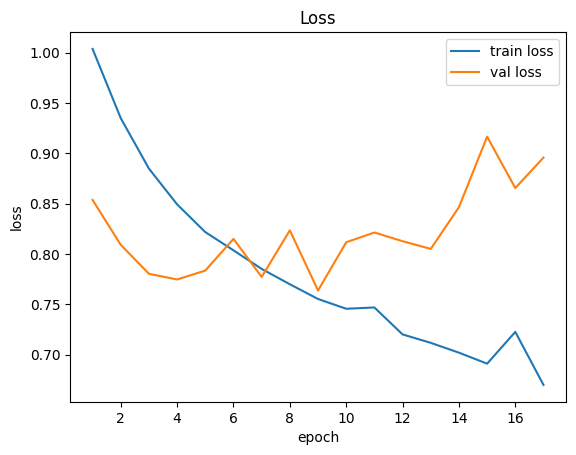

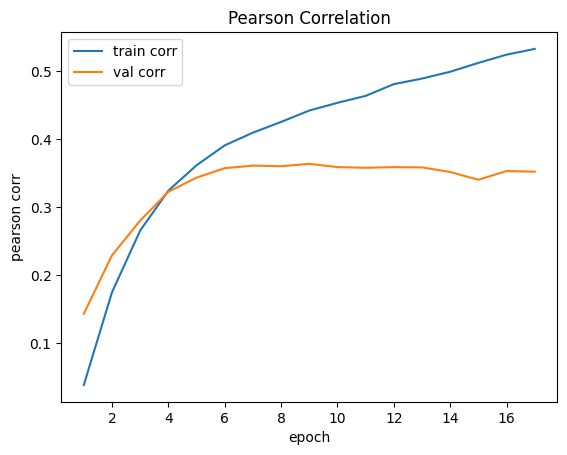

In [16]:
import matplotlib.pyplot as plt

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(epochs, history["train_corr"], label="train corr")
plt.plot(epochs, history["val_corr"], label="val corr")
plt.xlabel("epoch")
plt.ylabel("pearson corr")
plt.legend()
plt.title("Pearson Correlation")
plt.show()

### Post calibration

In [16]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Loaded checkpoint epoch:", ckpt.get("epoch"))

@torch.inference_mode()
def collect_preds_targets(model, loader):
    model.eval()
    P_list, Y_list = [], []
    for batch in tqdm(loader, desc="Collect preds", leave=False):
        xw = batch["x_wavlm"].to(DEVICE, non_blocking=True)
        xe = batch["x_er"].to(DEVICE, non_blocking=True)
        m  = batch["mask"].to(DEVICE, non_blocking=True)
        y  = batch["y"].to(DEVICE, non_blocking=True)  # NOTE: y is normalized in your pipeline

        p = model(xw, xe, m)

        P_list.append(p.detach().float().cpu())
        Y_list.append(y.detach().float().cpu())

    P = torch.cat(P_list, dim=0).numpy()  # normalized preds
    Y = torch.cat(Y_list, dim=0).numpy()  # normalized targets
    return P, Y

P_tr, Y_tr = collect_preds_targets(model, train_loader)
P_va, Y_va = collect_preds_targets(model, valid_loader)

print("Shapes:", P_tr.shape, Y_tr.shape, P_va.shape, Y_va.shape)

Loaded checkpoint epoch: 9


Collect preds:   0%|          | 0/247 [00:00<?, ?it/s]

Collect preds:   0%|          | 0/139 [00:00<?, ?it/s]

Shapes: (7873, 6) (7873, 6) (4429, 6) (4429, 6)


In [18]:
def denorm_np(y_norm: np.ndarray) -> np.ndarray:
    return y_norm * y_std[None, :] + y_mean[None, :]

def pearson_corr_np(preds: np.ndarray, targets: np.ndarray) -> float:
    # mean over columns
    eps = 1e-8
    vx = preds - preds.mean(axis=0, keepdims=True)
    vy = targets - targets.mean(axis=0, keepdims=True)
    corr = (vx * vy).sum(axis=0) / (np.sqrt((vx**2).sum(axis=0) * (vy**2).sum(axis=0)) + eps)
    return float(np.mean(corr))

def mse_np(preds: np.ndarray, targets: np.ndarray) -> float:
    return float(np.mean((preds - targets) ** 2))

# denorm to original scale for reporting
P_tr_d = denorm_np(P_tr)
Y_tr_d = denorm_np(Y_tr)
P_va_d = denorm_np(P_va)
Y_va_d = denorm_np(Y_va)

print("Before calibration:")
print(" Train  corr:", pearson_corr_np(P_tr_d, Y_tr_d), "mse:", mse_np(P_tr_d, Y_tr_d))
print(" Valid  corr:", pearson_corr_np(P_va_d, Y_va_d), "mse:", mse_np(P_va_d, Y_va_d))

Before calibration:
 Train  corr: 0.5061013102531433 mse: 0.03168729320168495
 Valid  corr: 0.36381348967552185 mse: 0.035572268068790436


In [19]:
def fit_linear_calibration(preds: np.ndarray, targets: np.ndarray):
    """
    Fit per-dimension y ≈ a*x + b via least squares.
    preds/targets: [N, K]
    returns:
      a: [K]
      b: [K]
    """
    K = preds.shape[1]
    a = np.zeros((K,), dtype=np.float64)
    b = np.zeros((K,), dtype=np.float64)

    for k in range(K):
        x = preds[:, k].astype(np.float64)
        y = targets[:, k].astype(np.float64)

        # Solve [x 1] [a b]^T = y
        A = np.stack([x, np.ones_like(x)], axis=1)  # [N,2]
        sol, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        ak, bk = sol[0], sol[1]

        if ak < 0:
            ak = 0.0

        a[k] = ak
        b[k] = bk

    return a.astype(np.float32), b.astype(np.float32)

a, b = fit_linear_calibration(P_tr_d, Y_tr_d)

print("Calibration params:")
for i, name in enumerate(EMOTIONS):
    print(f"{name:14s}  a={a[i]:.4f}  b={b[i]:.4f}")

# (optional) save
calib_path = OUT_DIR / "linear_calibration_ab.npz"
np.savez(calib_path, a=a, b=b, emotions=np.array(EMOTIONS))
print("Saved:", calib_path)

Calibration params:
Admiration      a=0.9476  b=0.0451
Amusement       a=1.0001  b=-0.0007
Determination   a=0.9561  b=0.0067
Empathic Pain   a=0.7837  b=0.0039
Excitement      a=0.8344  b=-0.0018
Joy             a=1.0105  b=-0.0168
Saved: /home/danila/networks/data/runs/audio_only_variant1_v1/linear_calibration_ab.npz


In [20]:
def apply_calibration(preds: np.ndarray, a: np.ndarray, b: np.ndarray):
    return preds * a[None, :] + b[None, :]

P_tr_cal = apply_calibration(P_tr_d, a, b)
P_va_cal = apply_calibration(P_va_d, a, b)

print("After calibration:")
print(" Train  corr:", pearson_corr_np(P_tr_cal, Y_tr_d), "mse:", mse_np(P_tr_cal, Y_tr_d))
print(" Valid  corr:", pearson_corr_np(P_va_cal, Y_va_d), "mse:", mse_np(P_va_cal, Y_va_d))

After calibration:
 Train  corr: 0.5061014890670776 mse: 0.03112304024398327
 Valid  corr: 0.3638138771057129 mse: 0.034504085779190063


### per-emotion

In [21]:
def per_emotion_corr(preds: np.ndarray, targets: np.ndarray):
    eps = 1e-8
    out = {}
    for i, name in enumerate(EMOTIONS):
        x = preds[:, i]; y = targets[:, i]
        vx = x - x.mean()
        vy = y - y.mean()
        c = (vx * vy).sum() / (np.sqrt((vx**2).sum() * (vy**2).sum()) + eps)
        out[name] = float(c)
    return out

def per_emotion_mse(preds: np.ndarray, targets: np.ndarray):
    out = {}
    for i, name in enumerate(EMOTIONS):
        out[name] = float(np.mean((preds[:, i] - targets[:, i])**2))
    return out

corr_before = per_emotion_corr(P_va_d, Y_va_d)
corr_after  = per_emotion_corr(P_va_cal, Y_va_d)
mse_before  = per_emotion_mse(P_va_d, Y_va_d)
mse_after   = per_emotion_mse(P_va_cal, Y_va_d)

print("Per-emotion VAL corr (before -> after):")
for k in EMOTIONS:
    print(f"{k:14s}  {corr_before[k]:.4f} -> {corr_after[k]:.4f}")

print("\nPer-emotion VAL mse (before -> after):")
for k in EMOTIONS:
    print(f"{k:14s}  {mse_before[k]:.6f} -> {mse_after[k]:.6f}")

Per-emotion VAL corr (before -> after):
Admiration      0.3860 -> 0.3860
Amusement       0.3462 -> 0.3462
Determination   0.3419 -> 0.3419
Empathic Pain   0.4700 -> 0.4700
Excitement      0.3431 -> 0.3431
Joy             0.2956 -> 0.2956

Per-emotion VAL mse (before -> after):
Admiration      0.052671 -> 0.051368
Amusement       0.044716 -> 0.044718
Determination   0.023721 -> 0.023570
Empathic Pain   0.004124 -> 0.003868
Excitement      0.047906 -> 0.043869
Joy             0.040296 -> 0.039631


## ------------------ additional ------------------

### try only one type of embeddings

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TCNBlock_SB(nn.Module):
    def __init__(self, d: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel - 1) * dilation // 2
        self.conv1 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        # GroupNorm more stable than BatchNorm when padding
        self.norm1 = nn.GroupNorm(1, d)
        self.norm2 = nn.GroupNorm(1, d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        res = x
        x = self.drop(F.gelu(self.norm1(self.conv1(x))))
        x = self.drop(F.gelu(self.norm2(self.conv2(x))))
        return x + res

class TCNEncoder_SB(nn.Module):
    def __init__(self, d: int, layers: int, kernel: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([
            TCNBlock_SB(d, kernel=kernel, dilation=2**i, dropout=dropout)
            for i in range(layers)
        ])

    def forward(self, x):
        # x: [B,T,d] -> [B,d,T]
        x = x.transpose(1, 2)
        for b in self.blocks:
            x = b(x)
        return x.transpose(1, 2)  # [B,T,d]

class AttentiveStatsPooling_SB(nn.Module):
    def __init__(self, d: int, attn_hidden: int, dropout: float, temp: float = 1.5):
        super().__init__()
        self.temp = temp
        self.attn = nn.Sequential(
            nn.Linear(d, attn_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_hidden, 1),
        )

    def forward(self, x, mask):
        # x: [B,T,d], mask: [B,T] bool
        logits = self.attn(x).squeeze(-1)  # [B,T]
        logits = logits / self.temp
        logits = logits.masked_fill(~mask, -1e4)

        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        w = w.unsqueeze(-1)  # [B,T,1]

        mu = (w * x).sum(dim=1)
        var = (w * (x - mu.unsqueeze(1)).pow(2)).sum(dim=1)
        std = torch.sqrt(var + 1e-6)
        return torch.cat([mu, std], dim=-1)  # [B,2d]

class AudioSingleBranch(nn.Module):
    def __init__(self, h_in: int, d_model: int, dropout: float, tcn_layers: int, tcn_kernel: int, attn_hidden: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(h_in, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.enc = TCNEncoder_SB(d_model, layers=tcn_layers, kernel=tcn_kernel, dropout=dropout)
        self.pool = AttentiveStatsPooling_SB(d_model, attn_hidden=attn_hidden, dropout=dropout, temp=1.5)

        in_dim = 2 * d_model
        self.head = nn.Sequential(
            nn.Linear(in_dim, 2 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2 * d_model, NUM_TARGETS),
        )

    def forward(self, x, mask):
        x = self.proj(x)
        x = self.enc(x)
        z = self.pool(x, mask)
        return self.head(z)

In [18]:
import random
import torch

def apply_time_mask_single(x: torch.Tensor, mask: torch.Tensor,
                           prob: float = 0.3, max_ratio: float = 0.08, num_masks: int = 1):
    """
    x: [B,T,H], mask: [B,T] bool
    """
    B, T, _ = x.shape
    for b in range(B):
        if random.random() > prob:
            continue
        valid_idx = mask[b].nonzero(as_tuple=False).squeeze(1)
        if valid_idx.numel() < 10:
            continue
        valid_T = int(valid_idx.numel())
        max_len = max(1, int(valid_T * max_ratio))
        for _ in range(num_masks):
            span = random.randint(1, max_len)
            start = random.randint(0, max(0, valid_T - span))
            t0 = int(valid_idx[start].item())
            t1 = int(valid_idx[start + span - 1].item()) + 1
            x[b, t0:t1] = 0.0
    return x

In [19]:
import math
import numpy as np
import torch
from tqdm.auto import tqdm

pearson_loss_fn = PearsonLoss()
mse_loss_fn = nn.MSELoss()

def compute_loss_and_corr_single(preds: torch.Tensor, targets: torch.Tensor, alpha_pearson: float):
    """
    preds/targets: [B,6] (your targets are already normalized if you have done target normalization)
    """
    loss_p = pearson_loss_fn(preds, targets)
    loss_m = mse_loss_fn(preds, targets)
    loss = alpha_pearson * loss_p + (1.0 - alpha_pearson) * loss_m
    corr = pearson_corr_torch(preds, targets)  # Pearson is invariant to normalization
    return loss, corr

@torch.inference_mode()
def eval_single(model, loader, branch: str, alpha_pearson: float):
    model.eval()
    losses = []
    all_p, all_y = [], []
    for batch in loader:
        m  = batch["mask"].to(DEVICE, non_blocking=True)
        y  = batch["y"].to(DEVICE, non_blocking=True)

        if branch == "wavlm":
            x = batch["x_wavlm"].to(DEVICE, non_blocking=True)
        else:
            x = batch["x_er"].to(DEVICE, non_blocking=True)

        p = model(x, m)
        loss, _ = compute_loss_and_corr_single(p, y, alpha_pearson)
        losses.append(float(loss.item()))
        all_p.append(p.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

    P = torch.cat(all_p, dim=0)
    Y = torch.cat(all_y, dim=0)
    _, corr = compute_loss_and_corr_single(P, Y, alpha_pearson)

    return {"loss": float(np.mean(losses)), "corr": float(corr.item())}

def train_single_branch(branch: str,
                        d_model: int = D_MODEL,
                        tcn_layers: int = TCN_LAYERS,
                        tcn_kernel: int = TCN_KERNEL,
                        dropout: float = DROPOUT,
                        attn_hidden: int = ATTN_HIDDEN,
                        lr: float = LR,
                        weight_decay: float = WEIGHT_DECAY,
                        max_epochs: int = 40,
                        patience: int = 8,
                        alpha_pearson: float = ALPHA_PEARSON,
                        use_time_mask: bool = True):
    """
    branch: "wavlm" or "er"
    Returns history + best checkpoint path.
    """

    # entrance dimensions
    sample = next(iter(train_loader))
    h_in = sample["x_wavlm"].shape[-1] if branch == "wavlm" else sample["x_er"].shape[-1]

    model_sb = AudioSingleBranch(
        h_in=h_in, d_model=d_model, dropout=dropout,
        tcn_layers=tcn_layers, tcn_kernel=tcn_kernel, attn_hidden=attn_hidden
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model_sb.parameters(), lr=lr, weight_decay=weight_decay)

    # cosine + warmup
    total_steps = max_epochs * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and USE_AMP))

    hist = {"train_loss": [], "train_corr": [], "val_loss": [], "val_corr": [], "lr": []}

    best_corr = -1e9
    best_epoch = -1
    bad = 0

    ckpt_path = OUT_DIR / f"best_{branch}.pt"

    for epoch in range(1, max_epochs + 1):
        model_sb.train()
        train_losses = []
        all_p, all_y = [], []

        for batch in tqdm(train_loader, desc=f"train {branch}", leave=False):
            m = batch["mask"].to(DEVICE, non_blocking=True)
            y = batch["y"].to(DEVICE, non_blocking=True)

            x = batch["x_wavlm"].to(DEVICE, non_blocking=True) if branch == "wavlm" else batch["x_er"].to(DEVICE, non_blocking=True)

            if use_time_mask and USE_TIME_MASK:
                x = apply_time_mask_single(x, m, prob=TIME_MASK_PROB, max_ratio=TIME_MASK_MAX_RATIO, num_masks=TIME_MASK_NUM)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
                p = model_sb(x, m)
                loss, _ = compute_loss_and_corr_single(p, y, alpha_pearson)

            if not torch.isfinite(loss):
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_sb.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_losses.append(float(loss.item()))
            all_p.append(p.detach().float().cpu())
            all_y.append(y.detach().float().cpu())

        P = torch.cat(all_p, dim=0)
        Y = torch.cat(all_y, dim=0)
        _, train_corr = compute_loss_and_corr_single(P, Y, alpha_pearson)

        train_loss = float(np.mean(train_losses))
        val_metrics = eval_single(model_sb, valid_loader, branch=branch, alpha_pearson=alpha_pearson)

        lr_now = optimizer.param_groups[0]["lr"]
        hist["train_loss"].append(train_loss)
        hist["train_corr"].append(float(train_corr.item()))
        hist["val_loss"].append(val_metrics["loss"])
        hist["val_corr"].append(val_metrics["corr"])
        hist["lr"].append(lr_now)

        print(
            f"[{branch}] Epoch {epoch:03d} | "
            f"train loss {train_loss:.4f} corr {float(train_corr.item()):.4f} | "
            f"val loss {val_metrics['loss']:.4f} corr {val_metrics['corr']:.4f} | lr {lr_now:.2e}"
        )

        # early stopping by corr
        if (val_metrics["corr"] - best_corr) > 1e-4:
            best_corr = val_metrics["corr"]
            best_epoch = epoch
            bad = 0
            torch.save({"epoch": epoch, "model_state": model_sb.state_dict(), "best_corr": best_corr, "history": hist}, ckpt_path)
            print(f"  ✅ saved best_{branch} by corr: epoch={epoch}, corr={best_corr:.4f}")
        else:
            bad += 1
            print(f"  ⏳ no corr improve: {bad}/{patience}")

        if bad >= patience:
            print(f"🛑 stop {branch}. best_epoch={best_epoch}, best_corr={best_corr:.4f}")
            break

    return model_sb, hist, ckpt_path

In [20]:
MAX_EPOCHS_ABL = 30
PATIENCE_ABL = 8

model_w, hist_w, ckpt_w = train_single_branch(
    branch="wavlm",
    max_epochs=MAX_EPOCHS_ABL,
    patience=PATIENCE_ABL,
    alpha_pearson=ALPHA_PEARSON,
    use_time_mask=True,
)

#model_e, hist_e, ckpt_e = train_single_branch(
#    branch="er",
#    max_epochs=MAX_EPOCHS_ABL,
#    patience=PATIENCE_ABL,
#    alpha_pearson=ALPHA_PEARSON,
#    use_time_mask=True,
#)

print("Saved:", ckpt_w, ckpt_e)

/tmp/ipykernel_36460/4108101581.py:84: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and USE_AMP))


train wavlm:   0%|          | 0/247 [00:00<?, ?it/s]

/tmp/ipykernel_36460/4108101581.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
/home/danila/networks/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


[wavlm] Epoch 001 | train loss 1.0565 corr 0.0175 | val loss 0.8494 corr 0.1086 | lr 3.34e-05
  ✅ saved best_wavlm by corr: epoch=1, corr=0.1086


train wavlm:   0%|          | 0/247 [00:00<?, ?it/s]

...

[er] Epoch 016 | train loss 0.9959 corr 0.0261 | val loss 0.8783 corr 0.0455 | lr 2.43e-05
  ⏳ no corr improve: 6/8


train er:   0%|          | 0/247 [00:00<?, ?it/s]

[er] Epoch 017 | train loss 0.9948 corr 0.0299 | val loss 0.8789 corr 0.0420 | lr 2.16e-05
  ⏳ no corr improve: 7/8


train er:   0%|          | 0/247 [00:00<?, ?it/s]

[er] Epoch 018 | train loss 0.9965 corr 0.0216 | val loss 0.8752 corr 0.0474 | lr 1.89e-05
  ⏳ no corr improve: 8/8
🛑 stop er. best_epoch=10, best_corr=0.0511
Saved: /home/danila/networks/data/runs/audio_only_variant1_v1/best_wavlm.pt /home/danila/networks/data/runs/audio_only_variant1_v1/best_er.pt


,branch,best_epoch,best_val_corr,val_loss_at_best_corr
0,wavlm_only,12,0.373204,0.793452
1,er_only,10,0.051065,0.872733


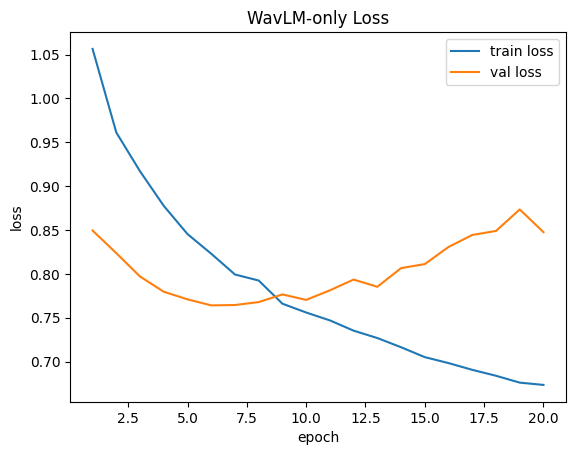

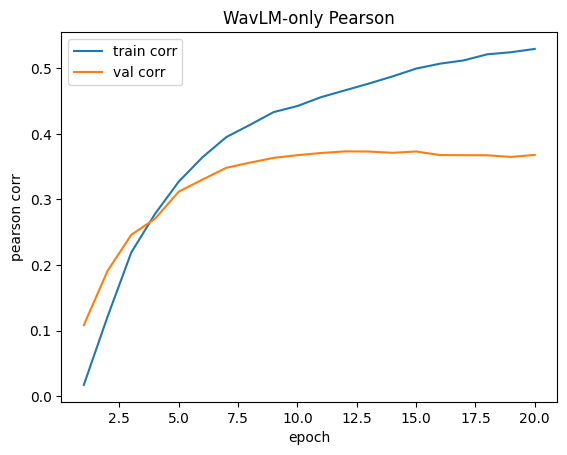

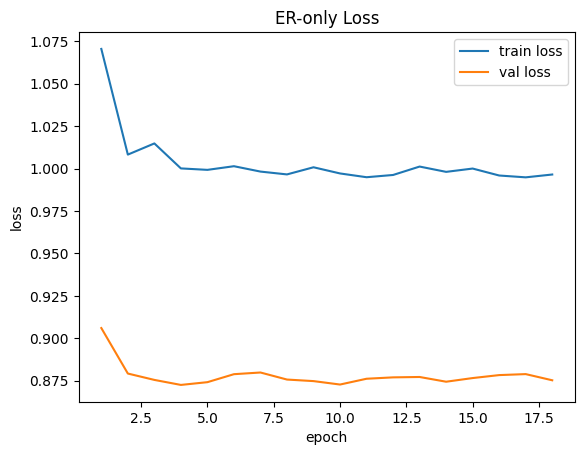

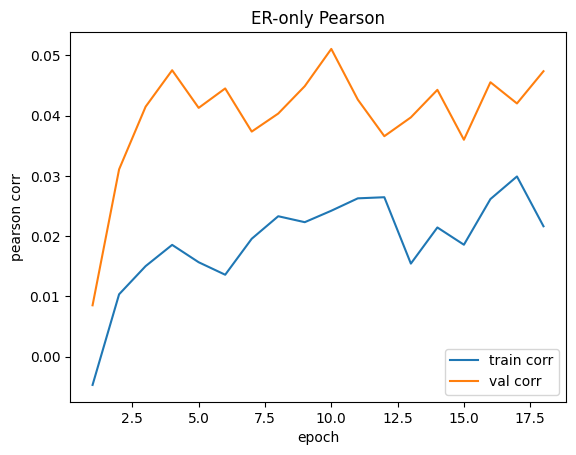

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def best_from_hist(hist):
    # best по val_corr
    idx = int(np.argmax(hist["val_corr"]))
    return {
        "best_epoch": idx + 1,
        "best_val_corr": hist["val_corr"][idx],
        "val_loss_at_best_corr": hist["val_loss"][idx],
    }

sum_w = best_from_hist(hist_w)
sum_e = best_from_hist(hist_e)

df_sum = pd.DataFrame([
    {"branch":"wavlm_only", **sum_w},
    {"branch":"er_only", **sum_e},
])
display(df_sum)

# plots
def plot_hist(hist, title_prefix):
    epochs = np.arange(1, len(hist["train_loss"]) + 1)
    plt.figure()
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(f"{title_prefix} Loss"); plt.legend(); plt.show()

    plt.figure()
    plt.plot(epochs, hist["train_corr"], label="train corr")
    plt.plot(epochs, hist["val_corr"], label="val corr")
    plt.xlabel("epoch"); plt.ylabel("pearson corr"); plt.title(f"{title_prefix} Pearson"); plt.legend(); plt.show()

plot_hist(hist_w, "WavLM-only")
plot_hist(hist_e, "ER-only")

# ------------------ more optimal with different loss ------------------

In [110]:
# CCC accumulation
CCC_ACCUM_STEPS = 32   # CCC is calculated on the prediction concat for 4 mini-batches (effective batch = BATCH_SIZE*4)
LAMBDA_SMOOTH = 0.02  # small stabilization (0.0 is possible for pure CCC)

In [111]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
import torch

def load_npz_embeddings(npz_path: Path):
    d = np.load(npz_path, allow_pickle=False)
    emb = d["embeddings"].astype(np.float32)
    valid = d["valid"].astype(bool) if "valid" in d.files else np.ones((emb.shape[0],), bool)
    return emb, valid

def filter_existing_wavlm(df: pd.DataFrame, wavlm_dir: Path, id_width: int = 5, min_valid_bins: int = 5):
    keep_rows = []
    missing = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Filter WavLM missing/empty"):
        vid = str(row["Filename"]).zfill(id_width)
        p = wavlm_dir / f"{vid}.npz"
        if not p.exists():
            missing.append({"video_id": vid, "reason": "wavlm_missing"})
            continue
        try:
            d = np.load(p, allow_pickle=False)
            v = d["valid"].astype(bool) if "valid" in d.files else np.ones((d["embeddings"].shape[0],), bool)
            if v.sum() < min_valid_bins:
                missing.append({"video_id": vid, "reason": f"too_few_valid<{min_valid_bins}"})
                continue
        except Exception as e:
            missing.append({"video_id": vid, "reason": f"npz_read_error:{repr(e)}"})
            continue
        keep_rows.append(row)
    return pd.DataFrame(keep_rows).reset_index(drop=True), pd.DataFrame(missing)

class AudioWavLMDataset(Dataset):
    def __init__(self, df: pd.DataFrame, wavlm_dir: Path, id_width: int, emotions: list[str], y_mean: np.ndarray, y_std: np.ndarray):
        self.df = df.reset_index(drop=True)
        self.wavlm_dir = wavlm_dir
        self.id_width = id_width
        self.emotions = emotions
        self.y_mean = y_mean.astype(np.float32)
        self.y_std = y_std.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        vid = str(row["Filename"]).zfill(self.id_width)

        wavlm_path = self.wavlm_dir / f"{vid}.npz"
        x, m = load_npz_embeddings(wavlm_path)

        y = np.array([row[e] for e in self.emotions], dtype=np.float32)
        # target normalization
        y = (y - self.y_mean) / self.y_std

        return {"video_id": vid, "x": x, "mask": m, "y": y}

def collate_pad_wavlm(batch):
    lengths = [b["x"].shape[0] for b in batch]
    maxT = max(lengths)
    H = batch[0]["x"].shape[1]

    x = torch.zeros((len(batch), maxT, H), dtype=torch.float32)
    mask = torch.zeros((len(batch), maxT), dtype=torch.bool)
    y = torch.zeros((len(batch), len(batch[0]["y"])), dtype=torch.float32)
    vids = []

    for i, b in enumerate(batch):
        T = b["x"].shape[0]
        x[i, :T] = torch.from_numpy(b["x"])
        mask[i, :T] = torch.from_numpy(b["mask"])
        y[i] = torch.from_numpy(b["y"])
        vids.append(b["video_id"])

    return {"video_id": vids, "x": x, "mask": mask, "y": y, "lengths": torch.tensor(lengths)}

In [112]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def ccc_torch(preds: torch.Tensor, targets: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    CCC averaged over columns.
    preds/targets: [N, K]
    """
    mx = preds.mean(0)
    my = targets.mean(0)
    vx = preds - mx
    vy = targets - my

    cov = (vx * vy).mean(0)
    var_x = (vx ** 2).mean(0)
    var_y = (vy ** 2).mean(0)

    ccc = (2 * cov) / (var_x + var_y + (mx - my) ** 2 + eps)
    return ccc.mean()

def ccc_loss(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    return 1.0 - ccc_torch(preds, targets)

def pearson_corr_torch(preds: torch.Tensor, targets: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    vx = preds - preds.mean(0)
    vy = targets - targets.mean(0)
    corr = (vx * vy).sum(0) / (torch.sqrt((vx**2).sum(0) * (vy**2).sum(0)) + eps)
    return corr.mean()

In [113]:
def pearson_loss(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    return 1.0 - pearson_corr_torch(preds, targets)

In [114]:
class TCNBlock(nn.Module):
    def __init__(self, d: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel - 1) * dilation // 2
        self.conv1 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.norm1 = nn.GroupNorm(1, d)
        self.norm2 = nn.GroupNorm(1, d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        res = x
        x = self.drop(F.gelu(self.norm1(self.conv1(x))))
        x = self.drop(F.gelu(self.norm2(self.conv2(x))))
        return x + res

class TCNEncoder(nn.Module):
    def __init__(self, d: int, layers: int, kernel: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([TCNBlock(d, kernel, 2**i, dropout) for i in range(layers)])

    def forward(self, x):
        x = x.transpose(1, 2)  # [B,d,T]
        for b in self.blocks:
            x = b(x)
        return x.transpose(1, 2)  # [B,T,d]

class AttentiveStatsPooling(nn.Module):
    def __init__(self, d: int, attn_hidden: int, dropout: float, temp: float = 1.5):
        super().__init__()
        self.temp = temp
        self.attn = nn.Sequential(
            nn.Linear(d, attn_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_hidden, 1),
        )

    def forward(self, x, mask):
        logits = self.attn(x).squeeze(-1) / self.temp
        logits = logits.masked_fill(~mask, -1e4)

        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        w = w.unsqueeze(-1)

        mu = (w * x).sum(dim=1)
        var = (w * (x - mu.unsqueeze(1)).pow(2)).sum(dim=1)
        std = torch.sqrt(var + 1e-6)
        return torch.cat([mu, std], dim=-1)

class AudioWavLMModel(nn.Module):
    def __init__(self, h_in: int, d_model: int, tcn_layers: int, tcn_kernel: int, dropout: float, attn_hidden: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(h_in, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.enc = TCNEncoder(d_model, tcn_layers, tcn_kernel, dropout)
        self.pool = AttentiveStatsPooling(d_model, attn_hidden, dropout, temp=1.5)
        self.head = nn.Sequential(
            nn.Linear(2*d_model, 2*d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2*d_model, NUM_TARGETS),
        )

    def forward(self, x, mask):
        x = self.proj(x)
        x = self.enc(x)
        z = self.pool(x, mask)
        return self.head(z)

In [115]:
class TCNBlock(nn.Module):
    def __init__(self, d: int, kernel: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel - 1) * dilation // 2
        self.conv1 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(d, d, kernel_size=kernel, dilation=dilation, padding=padding)
        self.norm1 = nn.GroupNorm(1, d)
        self.norm2 = nn.GroupNorm(1, d)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        res = x
        x = self.drop(F.gelu(self.norm1(self.conv1(x))))
        x = self.drop(F.gelu(self.norm2(self.conv2(x))))
        return x + res

class TCNEncoder(nn.Module):
    def __init__(self, d: int, layers: int, kernel: int, dropout: float):
        super().__init__()
        self.blocks = nn.ModuleList([TCNBlock(d, kernel, 2**i, dropout) for i in range(layers)])

    def forward(self, x):
        x = x.transpose(1, 2)  # [B,d,T]
        for b in self.blocks:
            x = b(x)
        return x.transpose(1, 2)  # [B,T,d]

class AttentiveStatsPooling(nn.Module):
    def __init__(self, d: int, attn_hidden: int, dropout: float, temp: float = 1.5):
        super().__init__()
        self.temp = temp
        self.attn = nn.Sequential(
            nn.Linear(d, attn_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_hidden, 1),
        )

    def forward(self, x, mask):
        logits = self.attn(x).squeeze(-1) / self.temp
        logits = logits.masked_fill(~mask, -1e4)

        w = torch.softmax(logits, dim=1)
        w = w * mask.float()
        w = w / (w.sum(dim=1, keepdim=True) + 1e-6)
        w = w.unsqueeze(-1)

        mu = (w * x).sum(dim=1)
        var = (w * (x - mu.unsqueeze(1)).pow(2)).sum(dim=1)
        std = torch.sqrt(var + 1e-6)
        return torch.cat([mu, std], dim=-1)

class AudioWavLMModel(nn.Module):
    def __init__(self, h_in: int, d_model: int, tcn_layers: int, tcn_kernel: int, dropout: float, attn_hidden: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(h_in, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )
        self.enc = TCNEncoder(d_model, tcn_layers, tcn_kernel, dropout)
        self.pool = AttentiveStatsPooling(d_model, attn_hidden, dropout, temp=1.5)
        self.head = nn.Sequential(
            nn.Linear(2*d_model, 2*d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2*d_model, NUM_TARGETS),
        )

    def forward(self, x, mask):
        x = self.proj(x)
        x = self.enc(x)
        z = self.pool(x, mask)
        return self.head(z)

In [116]:
import math
import numpy as np
import torch
from tqdm.auto import tqdm

smooth_loss_fn = nn.SmoothL1Loss(beta=0.2)

def train_epoch_pearson_accum(model, loader, optimizer, scaler, scheduler=None):
    model.train()

    group_losses = []
    all_pred, all_y = [], []

    buf_p, buf_y = [], []
    buf_count = 0

    for step, batch in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        x = batch["x"].to(DEVICE, non_blocking=True)
        m = batch["mask"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
            p = model(x, m)

        all_pred.append(p.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

        buf_p.append(p)
        buf_y.append(y)
        buf_count += 1

        is_flush = (buf_count >= CCC_ACCUM_STEPS) or (step == len(loader))
        if not is_flush:
            continue

        optimizer.zero_grad(set_to_none=True)

        P = torch.cat(buf_p, dim=0)
        Y = torch.cat(buf_y, dim=0)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
            loss_main = 1.0 - pearson_corr_torch(P, Y)  # Pearson loss
            loss = loss_main + (LAMBDA_SMOOTH * smooth_loss_fn(P, Y) if LAMBDA_SMOOTH > 0 else 0.0)

        if torch.isfinite(loss):
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()
            group_losses.append(float(loss.item()))

        buf_p, buf_y, buf_count = [], [], 0

    P_all = torch.cat(all_pred, dim=0)
    Y_all = torch.cat(all_y, dim=0)
    train_loss = float(np.mean(group_losses)) if group_losses else float("nan")
    train_corr = float(pearson_corr_torch(P_all, Y_all).item())
    return {"loss": train_loss, "corr": train_corr}

In [117]:
import math
import numpy as np
import torch
from tqdm.auto import tqdm

smooth_loss_fn = nn.SmoothL1Loss(beta=0.2)

def train_epoch_ccc_accum(model, loader, optimizer, scaler, scheduler=None):
    model.train()

    total_groups = 0
    group_losses = []

    # для метрики по эпохе
    all_pred = []
    all_y = []

    buf_p = []
    buf_y = []
    buf_smooth = 0.0
    buf_count = 0

    for step, batch in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        x = batch["x"].to(DEVICE, non_blocking=True)
        m = batch["mask"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
            p = model(x, m)  # [B,6]

        # копим для epoch-metrics (detach)
        all_pred.append(p.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

        # копим для CCC-loss (НЕ detach)
        buf_p.append(p)
        buf_y.append(y)

        # маленькая стабилизация (на уровне batch), без detach
        if LAMBDA_SMOOTH > 0:
            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
                buf_smooth = buf_smooth + smooth_loss_fn(p, y)

        buf_count += 1

        is_flush = (buf_count >= CCC_ACCUM_STEPS) or (step == len(loader))
        if not is_flush:
            continue

        optimizer.zero_grad(set_to_none=True)

        P = torch.cat(buf_p, dim=0)
        Y = torch.cat(buf_y, dim=0)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
            loss_main = ccc_loss(P, Y)
            if LAMBDA_SMOOTH > 0:
                loss = loss_main + LAMBDA_SMOOTH * (buf_smooth / buf_count)
            else:
                loss = loss_main

        if not torch.isfinite(loss):
            # сброс буфера и идём дальше
            buf_p, buf_y = [], []
            buf_smooth = 0.0
            buf_count = 0
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:
            scheduler.step()

        group_losses.append(float(loss.item()))
        total_groups += 1

        # reset buffers
        buf_p, buf_y = [], []
        buf_smooth = 0.0
        buf_count = 0

    # epoch metrics
    P_all = torch.cat(all_pred, dim=0)
    Y_all = torch.cat(all_y, dim=0)
    train_loss = float(np.mean(group_losses)) if group_losses else float("nan")
    train_corr = float(pearson_corr_torch(P_all, Y_all).item())

    return {"loss": train_loss, "corr": train_corr}

In [118]:
@torch.inference_mode()
def eval_epoch_ccc(model, loader):
    model.eval()
    all_pred = []
    all_y = []

    for batch in tqdm(loader, desc="eval", leave=False):
        x = batch["x"].to(DEVICE, non_blocking=True)
        m = batch["mask"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)

        p = model(x, m)
        all_pred.append(p.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

    P = torch.cat(all_pred, dim=0)
    Y = torch.cat(all_y, dim=0)

    val_loss = float(ccc_loss(P, Y).item())
    val_corr = float(pearson_corr_torch(P, Y).item())
    return {"loss": val_loss, "corr": val_corr}

In [119]:
@torch.inference_mode()
def eval_epoch_pearson(model, loader):
    model.eval()
    all_pred, all_y = [], []
    for batch in tqdm(loader, desc="eval", leave=False):
        x = batch["x"].to(DEVICE, non_blocking=True)
        m = batch["mask"].to(DEVICE, non_blocking=True)
        y = batch["y"].to(DEVICE, non_blocking=True)
        p = model(x, m)
        all_pred.append(p.detach().float().cpu())
        all_y.append(y.detach().float().cpu())

    P = torch.cat(all_pred, dim=0)
    Y = torch.cat(all_y, dim=0)
    corr = float(pearson_corr_torch(P, Y).item())
    loss = float((1.0 - corr) + (LAMBDA_SMOOTH * smooth_loss_fn(P, Y).item() if LAMBDA_SMOOTH > 0 else 0.0))
    return {"loss": loss, "corr": corr}

In [120]:
import torch
from torch.utils.data import DataLoader

# --- read CSV as before (dtype=str, zfill) ---
train_df = pd.read_csv(TRAIN_CSV, dtype={"Filename": str})
valid_df = pd.read_csv(VALID_CSV, dtype={"Filename": str})
train_df["Filename"] = train_df["Filename"].str.zfill(ID_WIDTH)
valid_df["Filename"] = valid_df["Filename"].str.zfill(ID_WIDTH)

# --- compute target norm on TRAIN ---
y_train = train_df[EMOTIONS].values.astype(np.float32)
y_mean = y_train.mean(axis=0)
y_std  = np.clip(y_train.std(axis=0), 1e-3, None)

# --- filter wavlm missing ---
train_df_ok, train_missing = filter_existing_wavlm(train_df, WAVLM_DIR, ID_WIDTH, min_valid_bins=5)
valid_df_ok, valid_missing = filter_existing_wavlm(valid_df, WAVLM_DIR, ID_WIDTH, min_valid_bins=5)
print("Train ok:", len(train_df_ok), "Val ok:", len(valid_df_ok))

train_ds = AudioWavLMDataset(train_df_ok, WAVLM_DIR, ID_WIDTH, EMOTIONS, y_mean, y_std)
valid_ds = AudioWavLMDataset(valid_df_ok, WAVLM_DIR, ID_WIDTH, EMOTIONS, y_mean, y_std)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          collate_fn=collate_pad_wavlm, drop_last=False, persistent_workers=(NUM_WORKERS>0))
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          collate_fn=collate_pad_wavlm, drop_last=False, persistent_workers=(NUM_WORKERS>0))

# --- init model ---
sample = next(iter(train_loader))
H_IN = sample["x"].shape[-1]
model = AudioWavLMModel(H_IN, D_MODEL, TCN_LAYERS, TCN_KERNEL, DROPOUT, ATTN_HIDDEN).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))

# cosine + warmup (шаги считаем по "группам" аккумуляции)
steps_per_epoch_groups = math.ceil(len(train_loader) / CCC_ACCUM_STEPS)
total_steps = MAX_EPOCHS * steps_per_epoch_groups
warmup_steps = int(0.05 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

Filter WavLM missing/empty:   0%|          | 0/8072 [00:00<?, ?it/s]

Filter WavLM missing/empty:   0%|          | 0/4588 [00:00<?, ?it/s]

Train ok: 7873 Val ok: 4429


/tmp/ipykernel_36460/3064061491.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))


In [121]:
import json
import numpy as np

history = {"train_loss": [], "train_corr": [], "val_loss": [], "val_corr": [], "lr": []}

best_corr = -1e9
best_epoch = -1
bad = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr = train_epoch_ccc_accum(model, train_loader, optimizer, scaler, scheduler=scheduler)
    va = eval_epoch_pearson(model, valid_loader)

    lr_now = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(tr["loss"])
    history["train_corr"].append(tr["corr"])
    history["val_loss"].append(va["loss"])
    history["val_corr"].append(va["corr"])
    history["lr"].append(lr_now)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss {tr['loss']:.4f} corr {tr['corr']:.4f} | "
        f"val loss {va['loss']:.4f} corr {va['corr']:.4f} | "
        f"lr {lr_now:.2e}"
    )

    if (va["corr"] - best_corr) > MIN_DELTA:
        best_corr = va["corr"]
        best_epoch = epoch
        bad = 0

        torch.save({"epoch": epoch, "model_state": model.state_dict(), "best_corr": best_corr}, CKPT_PATH)
        with open(HIST_PATH, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)

        print(f"  ✅ Saved best-by-corr: epoch={epoch}, val_corr={best_corr:.4f}")
    else:
        bad += 1
        print(f"  ⏳ no corr improve: {bad}/{PATIENCE}")

    if bad >= PATIENCE:
        print(f"🛑 Early stopping. Best epoch={best_epoch}, best val corr={best_corr:.4f}")
        break

train:   0%|          | 0/247 [00:00<?, ?it/s]

/tmp/ipykernel_36460/409472975.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
/tmp/ipykernel_36460/409472975.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):
/tmp/ipykernel_36460/409472975.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda" and USE_AMP)):


eval:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 001 | train loss 1.0022 corr 0.0180 | val loss 0.9301 corr 0.0810 | lr 2.00e-04
  ✅ Saved best-by-corr: epoch=1, val_corr=0.0810


train:   0%|          | 0/247 [00:00<?, ?it/s]

...

eval:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 018 | train loss 0.4414 corr 0.5714 | val loss 0.6840 corr 0.3309 | lr 3.80e-04
  ⏳ no corr improve: 7/8


train:   0%|          | 0/247 [00:00<?, ?it/s]

eval:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 019 | train loss 0.4334 corr 0.5771 | val loss 0.6803 corr 0.3346 | lr 3.65e-04
  ⏳ no corr improve: 8/8
🛑 Early stopping. Best epoch=11, best val corr=0.3668


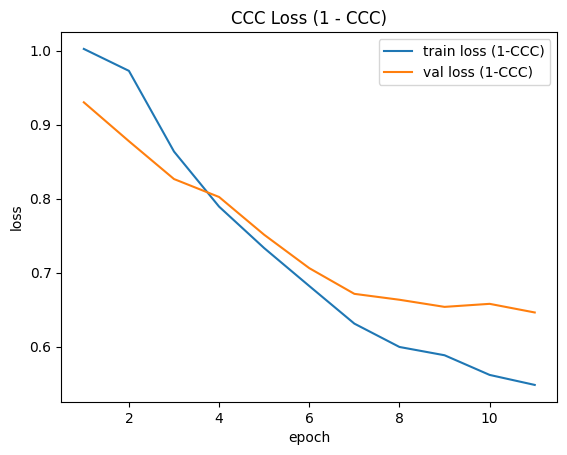

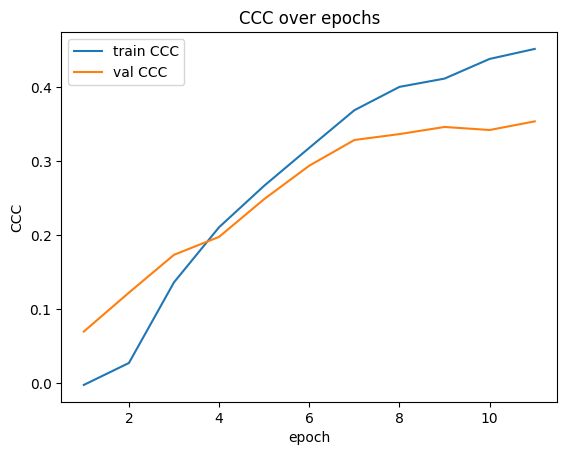

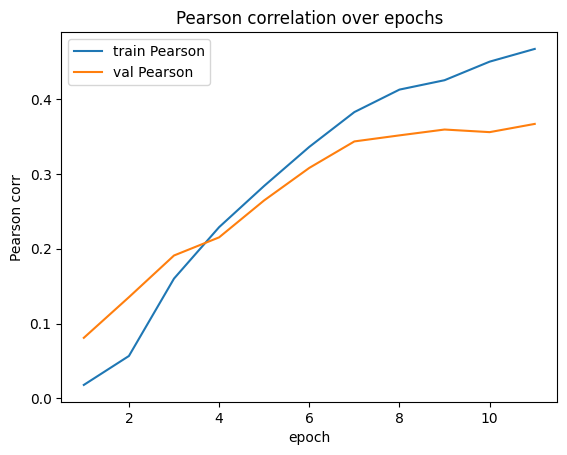

In [122]:
with open(HIST_PATH, "r", encoding="utf-8") as f:
    history = json.load(f)

epochs = np.arange(1, len(history["train_loss"]) + 1)

# Loss curves (loss = 1 - CCC)
plt.figure()
plt.plot(epochs, history["train_loss"], label="train loss (1-CCC)")
plt.plot(epochs, history["val_loss"], label="val loss (1-CCC)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("CCC Loss (1 - CCC)")
plt.legend()
plt.show()

# CCC curves (CCC = 1 - loss)
train_ccc = 1.0 - np.array(history["train_loss"], dtype=np.float32)
val_ccc   = 1.0 - np.array(history["val_loss"], dtype=np.float32)

plt.figure()
plt.plot(epochs, train_ccc, label="train CCC")
plt.plot(epochs, val_ccc, label="val CCC")
plt.xlabel("epoch")
plt.ylabel("CCC")
plt.title("CCC over epochs")
plt.legend()
plt.show()

# Pearson corr curves
plt.figure()
plt.plot(epochs, history["train_corr"], label="train Pearson")
plt.plot(epochs, history["val_corr"], label="val Pearson")
plt.xlabel("epoch")
plt.ylabel("Pearson corr")
plt.title("Pearson correlation over epochs")
plt.legend()
plt.show()

In [123]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

train_metrics = eval_epoch_pearson(model, train_loader)
val_metrics   = eval_epoch_pearson(model, valid_loader)

print("Loaded best checkpoint epoch:", ckpt.get("epoch"))
print("Train:", train_metrics)
print("Val  :", val_metrics)

print("Train CCC:", 1.0 - train_metrics["loss"])
print("Val   CCC:", 1.0 - val_metrics["loss"])

eval:   0%|          | 0/247 [00:00<?, ?it/s]

eval:   0%|          | 0/139 [00:00<?, ?it/s]

Loaded best checkpoint epoch: 11
Train: {'loss': 0.5005924379825593, 'corr': 0.5117820501327515}
Val  : {'loss': 0.6462850499153138, 'corr': 0.36681053042411804}
Train CCC: 0.49940756201744074
Val   CCC: 0.35371495008468623


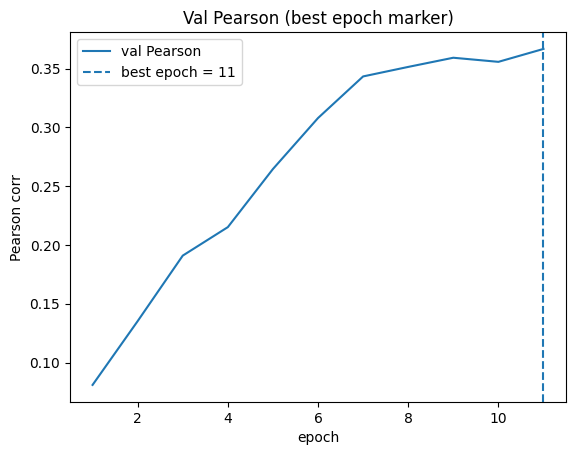

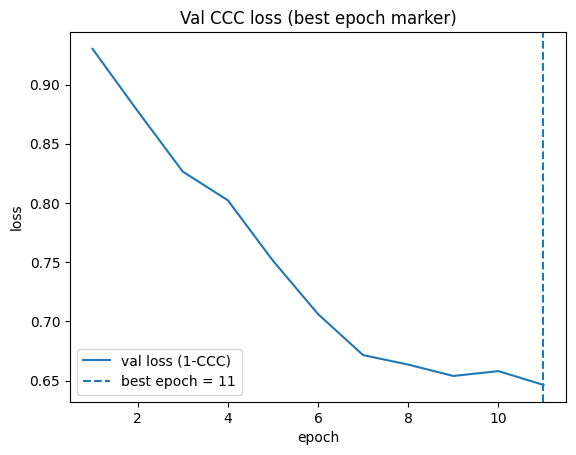

In [124]:
best_epoch = int(ckpt.get("epoch", np.argmax(history["val_corr"]) + 1))

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["val_corr"], label="val Pearson")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("Pearson corr")
plt.title("Val Pearson (best epoch marker)")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, history["val_loss"], label="val loss (1-CCC)")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Val CCC loss (best epoch marker)")
plt.legend()
plt.show()